In [1]:
# Import required packages
import torch
from torch import nn
from torch.distributions import Uniform
import numpy as np
import normflows as nf

from matplotlib import pyplot as plt

from tqdm import tqdm
from asrl.realnvp2d.nf.realnvp2d import init_realnvp2d
from time import perf_counter

Z shape: torch.Size([2, 2, 128])
C shape: torch.Size([2, 2])


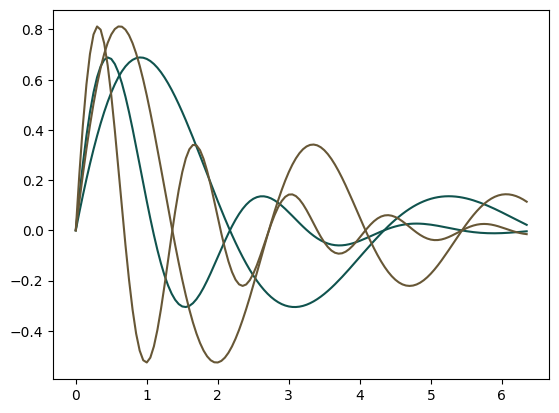

In [2]:
n_channels = 2
horizon = 128
context_dim = 2


class SinDataset:
    def __init__(self, horizon):
        self.horizon = horizon
    
        self.sin_rate = Uniform(1.0, 6.0)
        self.exp_rate = Uniform(0.5, 2.0)
        
        self.sz = 10_000
        self.samples, self.conds = self._sample(self.sz)
    
    def sample(self, n_samples):
        inds = torch.randint(0, self.sz, (n_samples,))
        return self.samples[inds, :, :], self.conds[inds, :]
    
    def _sample(self, n_samples):
        dt = 0.05
        ts_integer = torch.arange(0, self.horizon, 1).reshape(1, -1)
        ts_integer = torch.tile(ts_integer, (n_samples, 1))
        ts_float = ts_integer.float() * dt
                
        sin_rates = self.sin_rate.sample((n_samples, 1))
        exp_rates = self.exp_rate.sample((n_samples, 1))
        
        COND = torch.cat([sin_rates, exp_rates], dim=1)
        CH1 = torch.sin(sin_rates * ts_float) * torch.exp(-exp_rates * ts_float)
        CH2 = torch.sin(sin_rates/2 * ts_float) * torch.exp(-exp_rates/2 * ts_float)
        
        X = torch.stack([CH1, CH2], dim=1)
        return X, COND

target = SinDataset(horizon)

n_samples = 2
Z, C = target.sample(n_samples)
print(f"Z shape: {Z.shape}")
print(f"C shape: {C.shape}")

for i in range(n_samples):
    # pick a random color
    ts = torch.arange(0, horizon, 1).float() * 0.05
    X = Z[i, 0, :]
    Y = Z[i, 1, :]
    color = np.random.rand(3,)
    
    plt.plot(ts.numpy(), X.numpy(), color=color)
    plt.plot(ts.numpy(), Y.numpy(), color=color)
    

In [3]:
model = init_realnvp2d(n_channels=n_channels, seq_len=horizon, n_layers=3, context_dim=context_dim)
enable_cuda = True
device = torch.device('cuda' if torch.cuda.is_available() and enable_cuda else 'cpu')
model = model.to(device)

# Print number of params in model
print(f"Number of parameters in the model: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

Initializing RealNVP2D with 3 layers and 2 channels for a sequence of length 128
Level 0, Layer 0; mask shape=torch.Size([2, 128]), even=True (checkerboard)
Level 0, Layer 1; mask shape=torch.Size([2, 128]), even=False (checkerboard)
Level 0, Layer 2; mask shape=torch.Size([2, 128]), even=True (checkerboard)
Level 0, Layer 0; mask shape=torch.Size([4, 64]), even=False (mid channel split)
Level 0, Layer 1; mask shape=torch.Size([4, 64]), even=True (mid channel split)
Level 0, Layer 2; mask shape=torch.Size([4, 64]), even=False (mid channel split)
Level 1, Layer 0; mask shape=torch.Size([4, 64]), even=False (checkerboard)
Level 1, Layer 1; mask shape=torch.Size([4, 64]), even=True (checkerboard)
Level 1, Layer 2; mask shape=torch.Size([4, 64]), even=False (checkerboard)
Level 1, Layer 0; mask shape=torch.Size([8, 32]), even=True (mid channel split)
Level 1, Layer 1; mask shape=torch.Size([8, 32]), even=False (mid channel split)
Level 1, Layer 2; mask shape=torch.Size([8, 32]), even=True 

In [4]:
# Train model
max_iter = 10_000
num_samples = 256
show_iter = 500

loss_hist = np.array([])

stats = {
    'target_sample_time': 0.0,
    'forward_time': 0.0,
    'backward_time': 0.0,
    'optimizer_step_time': 0.0,
}

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

for it in tqdm(range(max_iter)):
    optimizer.zero_grad()
    
    # Get training samples
    start = perf_counter()
    x, c = target.sample(num_samples)
    x = x.to(device)  # Move data to device
    c = c.to(device)  # Move conditions to device
    
    stats['target_sample_time'] += perf_counter() - start
        
    # Compute loss
    start = perf_counter()
    loss = model.forward_kld(x, context=c)
    stats['forward_time'] += perf_counter() - start
    
    # Do backprop and optimizer step
    if ~(torch.isnan(loss) | torch.isinf(loss)):
        start = perf_counter()
        loss.backward()
        stats['backward_time'] += perf_counter() - start
        
        start = perf_counter()
        optimizer.step()
        stats['optimizer_step_time'] += perf_counter() - start
    
    # Log loss
    loss_hist = np.append(loss_hist, loss.to('cpu').data.numpy())
    
    # Plot learned distribution
    if it % show_iter == 0:
        print(f'Iter {it + 1}/{max_iter}, Loss: {loss_hist[-1]}')
        print(f'Stats:')
        print(f'  Target sample time: {stats["target_sample_time"]/show_iter:.6f}s')
        print(f'  Forward time: {stats["forward_time"]/show_iter:.6f}s')
        print(f'  Backward time: {stats["backward_time"]/show_iter:.6f}s')
        print(f'  Optimizer step time: {stats["optimizer_step_time"]/show_iter:.6f}s')
        
        # Reset stats
        stats['target_sample_time'] = 0.0
        stats['forward_time'] = 0.0
        stats['backward_time'] = 0.0
        stats['optimizer_step_time'] = 0.0

# Plot loss
plt.figure(figsize=(10, 10))
plt.plot(loss_hist, label='loss')
plt.legend()
plt.show()


  0%|          | 3/10000 [00:00<22:55,  7.27it/s]

Iter 1/10000, Loss: 241.0415802001953
Stats:
  Target sample time: 0.000002s
  Forward time: 0.000374s
  Backward time: 0.000179s
  Optimizer step time: 0.000079s


  5%|▌         | 503/10000 [00:28<08:46, 18.04it/s]

Iter 501/10000, Loss: -1429.8349609375
Stats:
  Target sample time: 0.000530s
  Forward time: 0.019353s
  Backward time: 0.018376s
  Optimizer step time: 0.003764s


 10%|█         | 1003/10000 [00:56<08:07, 18.44it/s]

...

Iter 4001/10000, Loss: -2088.416748046875
Stats:
  Target sample time: 0.000527s
  Forward time: 0.018375s
  Backward time: 0.017840s
  Optimizer step time: 0.003730s


 45%|████▌     | 4503/10000 [04:12<05:00, 18.31it/s]

Iter 4501/10000, Loss: -2076.7978515625
Stats:
  Target sample time: 0.000536s
  Forward time: 0.018035s
  Backward time: 0.017732s
  Optimizer step time: 0.003757s


 45%|████▌     | 4547/10000 [04:14<05:05, 17.86it/s]


KeyboardInterrupt: 

Contexts from dataset:
tensor([[5.3277, 1.0299]])


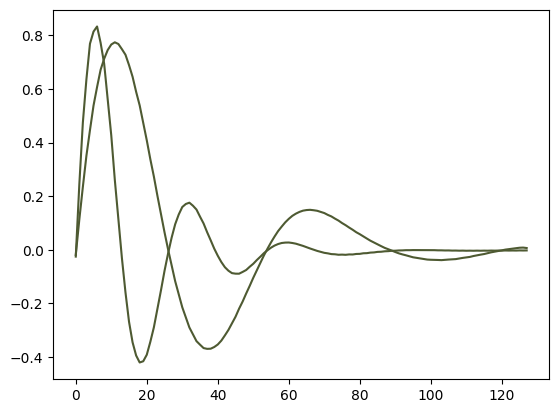

In [58]:
dataset_samples, dataset_contexts = target.sample(n_samples=1)
print("Contexts from dataset:")
print(dataset_contexts)

model_samples = model.sample(num_samples=dataset_contexts.shape[0], context=dataset_contexts.to(device))
samples, _ = model_samples

for i in range(samples.shape[0]):
    color = np.random.rand(3,)
    
    for j in range(n_channels):
        ch1 = samples[i, j, :].cpu().detach().numpy()
        plt.plot(ch1, color=color)

plt.show()